<a href="https://colab.research.google.com/github/jessieaha/CAMS_dust_deduction_tool/blob/main/Dust_deduction_tool_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Dust service Tool

This notebook presents a prototype of the <u>**CAMS Natural Dust service Tool**</u> designed to support EU Member States in identifying and assessing natural contributions from dust to PM10 concentrations, as requested by Article 16 of the Air Quality Directive (AAQD 2024/2881). The tool aims to calculate and subtract these natural dust contributions from measured PM10 concentrations to provide corrected PM10 surface concentrations.

> AAQD (2024/2881) Article 16: Member states are requested to identify a) zones where exceedances of limit values for a given pollutant are attributable to natural sources and b) average exposure territorial units, where exceedances of the level determined by the average exposure reduction obligations are attributable to natural sources.

This *natural dust service tool prototype* is based on the methodology provided in the European Commission DG-ENV  guidelines ([sec 2011-0208](https://data.consilium.europa.eu/doc/document/ST%206771%202011%20INIT/EN/pdf)) for the assessment of the natural contributions from dust, which needs to be followed to allow subtraction of these contributions from the reported PM concentrations.
For flagging the presence of natural dust the CAMS interim reanalysis dust product is used.

This prototype is demonstrating the methodology and applications of the tool for 2024 and daily EEA data in Spain.

# Outline
- [ 1 - Import Packages ](#1)
- [ 2 - Country selection and Threshold settings](#2)
- [ 3 - Data preparation ](#3)
- [ 4 - Flag dust days with CAMS data](#4)
- [ 5 - Calculate dust for days with dust and exceedance](#5)
- [ 6 - Table with results](#6)
- [ 7 - Visualization](#7)

<a name="1"></a>
## 1 - Import Packages

Output should show in the lastline:

> util.py has been imported




In [1]:
# %%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests
import os
import glob
import zipfile
import calendar
#!pip install xarray netcdf4 
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import urllib.request
import json
import io
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
# raw_url="https://raw.githubusercontent.com/jessieaha/CAMS_dust_deduction_tool/main/util.py"
# dest = Path('util.py')
# urllib.request.urlretrieve(raw_url, dest)
from util import *
print(until_check())

util.py has been imported



<details>
<summary><font size="2" color="darkgreen"><b>Please Click here if errors appear</b></font></summary>
Remove <font size="2" color="blue"> <b>%%capture</b></font> and output should show in the end:

> util.py has been imported

If functions are modified in util.py please reload the file use the code below
```
import sys, importlib, os, inspect
import util
importlib.invalidate_caches()
if 'util' in sys.modules:
    del sys.modules['util']
import util
importlib.reload(util)  # extra safety

# Double-check the function exists and from which file it's loaded
print("Has function?", hasattr(util, 'plot_station_timeseries'))
if hasattr(util, 'plot_station_timeseries'):
    print(inspect.getsource(util.plot_station_timeseries)[:400])  # peek at the first lines

```
If one of the modules are not loading  try

```
pip install xxxx
```
If you plan to run this notebook in the VScode or in HPC environment, the widget from interactive plot might not work but you can modify the code by inputing correct column to generate static plots. Cheers!




<a name="2"></a>
## 2- Country selection and Threshold settings
Choose the country of interest for downloading the observation data. Note that only SPAIN (ES) is available in this prototype based on a predownloaded daily EEA dataset.

In the final tool you will be able to select other countries to download daily or hourly EEA datasets (E1a or E2a) for chosen year. You will also be able to choose to use your own observation dataset.
<center>


| Country Code | Country Name           | Country Code | Country Name           |
|-------------|-------------------------|-------------|-------------------------|
| AD          | Andorra                | IT          | Italy                  |
| AL          | Albania                | LT          | Lithuania              |
| AT          | Austria                | LU          | Luxembourg             |
| BA          | Bosnia and Herzegovina | LV          | Latvia                 |
| BE          | Belgium                | ME          | Montenegro             |
| BG          | Bulgaria               | MK          | North Macedonia        |
| CH          | Switzerland            | MT          | Malta                  |
| CY          | Cyprus                 | NL          | Netherlands            |
| CZ          | Czechia                | NO          | Norway                 |
| DE          | Germany                | PL          | Poland                 |
| DK          | Denmark                | PT          | Portugal               |
| EE          | Estonia                | RO          | Romania                |
| ES          | Spain                  | RS          | Serbia                 |
| FI          | Finland                | SE          | Sweden                 |
| FR          | France                 | SI          | Slovenia               |
| GB          | United Kingdom         | SK          | Slovakia               |
| GR          | Greece                 | XK          | Kosovo                |  
| HR          | Croatia                |             |                         |
| HU          | Hungary                |             |                         |
| IE          | Ireland                |             |                         |
| IS          | Iceland                |             |                         |




In [33]:
project_dir          = '/tsn.tno.nl/Data/SV/sv-059025_unix/ProjectData/EU/CAMS/C71/Werkdocumenten/wp-dust/'
# project_dir          = '.'
EEA_temporal_flag    = 'day'    # hour or day 
dataset              = 'E1a'
EEA_folder_path      = f'EEA_PM10/{dataset}/{EEA_temporal_flag}'
CAMS_folder_path     = f'{project_dir}/IRA_dust/'
# CAMS_folder_path_pm10     = f'{project_dir}/IRA_particulate_matter_10um/'
DOWNLOAD_EEA         = False
DOWNLOAD_CAMS        = False
COMPUTE_CAMS_DAILY   = False
Countries            = ["AD", "AL", "AT", "BA", "BE", "BG", "CH", "CY", "CZ", "DE", "DK", "EE", "ES", "FI", "FR", "GB", "GR", "HR", "HU", "IE", "IS", "IT", "LT", "LU", "LV", "ME", "MK", "MT", "NL", "NO", "PL", "PT", "RO", "RS", "SE", "SI", "SK", "XK"]        # select countries
YEAR                 = 2024      # int: target year 
cams_dust_threshold  = 5         # unit: ug/m3
PM10_daily_threshold = 50  # 50 µg m-3


In [3]:
if (DOWNLOAD_EEA):
    from datetime import datetime
    # Specify download path
    os.makedirs(EEA_folder_path, exist_ok=True)

    apiUrl = "https://eeadmz1-downloads-api-appservice.azurewebsites.net/"
    endpoint = "ParquetFile/async"

    fileName = os.path.join(EEA_folder_path, f"EEA_{YEAR}.zip")
    request_body = {
        "countries": Countries,
        "cities": [],
        "pollutants": ["PM10"],
        "dataset": 2,
        "dateTimeStart": f"{YEAR-1}-12-14T00:00:00Z",
        "dateTimeEnd": "2024-12-31T23:59:59Z",
        "aggregationType": EEA_temporal_flag,
        "email": ""
    }

    response = requests.post(f"{apiUrl}{endpoint}", json=request_body)
    downloadFile = response.text
    print(downloadFile)

    t_start = datetime.now()
    while True:
        if (datetime.now() - t_start).total_seconds() > 3600:  # stop after 1 hour if the file has not been created
            break
        parquetResponse = requests.get(downloadFile)
        if parquetResponse.status_code == 404:
            time.sleep(20)
        else:
            break

    with open(fileName, "wb") as fp:
        fp.write(parquetResponse.content)

    with zipfile.ZipFile(fileName, 'r') as zip_ref:
        zip_ref.extractall(EEA_folder_path)

Please go to https://cds.climate.copernicus.eu/how-to-api to see how to use cdsapi
if you already have an account but forgot your key please go to your profile and copy API key like below.
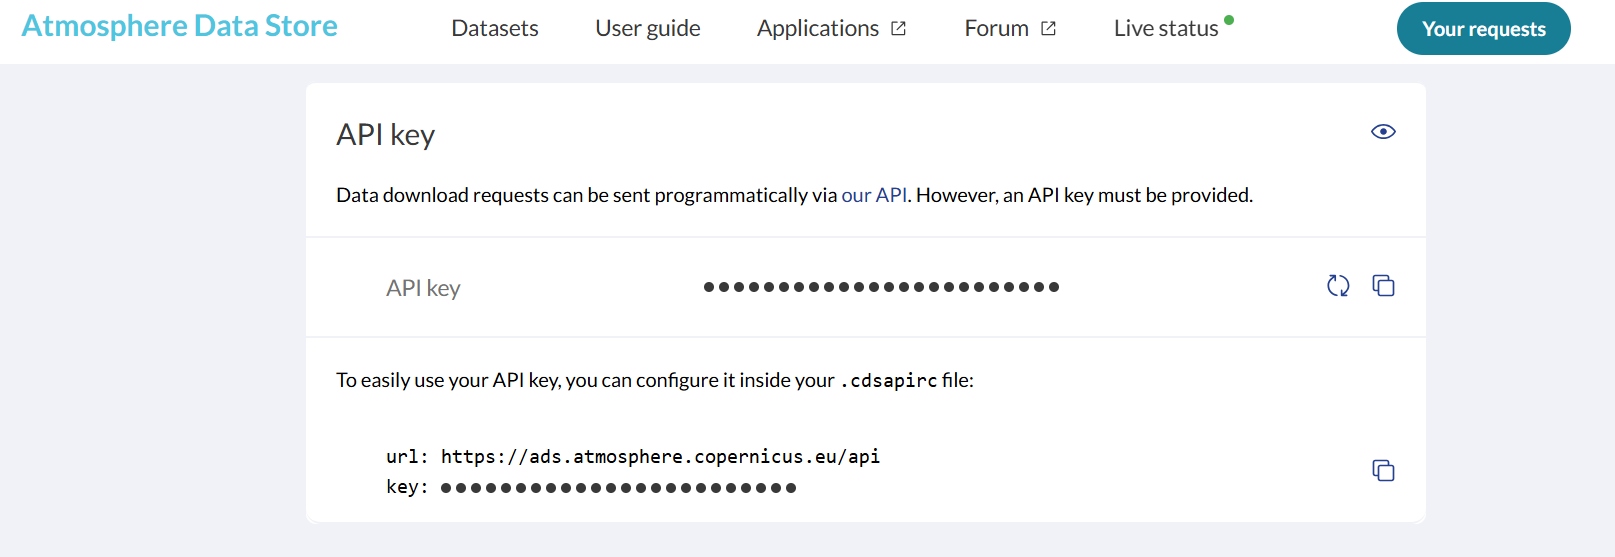

if you need to create or regenerate login key for ads or cds, please uncomment the cell below
If error appeared please try !pip install --user "cdsapi>=0.7.7"

In [4]:
# import os
# # if you want to regenerate your api key, uncomment below:
# # !rm  ~/.cdsapirc
# # Ask for user input
# path = os.path.expanduser('~/.cdsapirc')

# # 1. Check if the file already exists
# if os.path.exists(path):
#     print(f"Skipping: Configuration file already exists at {path}")
# else:
#   api_key = input("Enter your Copernicus CDS API Key: ")

#   # Define the content and path
#   path = os.path.expanduser('~/.cdsapirc')
#   content = f"""url: https://ads.climate.copernicus.eu/api
#   # key: {api_key}"""
#   # content = "url: https://ads.atmosphere.copernicus.eu/api \nkey:"

#   # Write the file
#   with open(path, 'w') as f:
#       f.write(content)

#   print(f"\nSuccess! .cdsapirc has been created at {path}")
# !ls -a ~ | grep .cdsapirc
# !cat  ~/.cdsapirc
# !pip install --user "cdsapi>=0.7.7"

In [5]:
if (DOWNLOAD_CAMS):
    import cdsapi
    VAR = "dust" #"dust" "particulate_matter_10um"
    YEAR = 2024
    project_dir ='./'
    CAMS_folder_path =f'{project_dir}wp-dust/IRA_{VAR}/'

    os.makedirs(CAMS_folder_path, exist_ok=True)

    cams_downloads = [
        {"filename": f"CAMS_IRA_{(YEAR-1)}_12.zip", "year": [f"{(YEAR-1)}"], "month": ["12"]},
        {"filename": F"CAMS_IRA_{(YEAR)}_q1.zip", "year": [f"{YEAR}"], "month": ["01","02","03"]},
        {"filename": F"CAMS_IRA_{(YEAR)}_q2.zip", "year": [f"{YEAR}"], "month": ["04","05","06"]},
        {"filename": F"CAMS_IRA_{(YEAR)}_q3.zip", "year": [f"{YEAR}"], "month": ["07","08","09"]},
        {"filename": F"CAMS_IRA_{(YEAR)}_q4.zip", "year": [f"{YEAR}"], "month": ["10","11","12"]}
    ]

    dataset = "cams-europe-air-quality-reanalyses"
    client = cdsapi.Client()

    for config in cams_downloads:
        filename = os.path.join(CAMS_folder_path, config["filename"])
        request = {
            "variable": [VAR],
            "model": ["ensemble"],
            "level": ["0"],
            "type": ["interim_reanalysis"],
            "year": config["year"],
            "month": config["month"]
        }

        client.retrieve(dataset, request).download(filename)


    # Get list of all files in the current directory
    files = glob.glob(f'{CAMS_folder_path}/*zip')

    for file in files:

        print(f"Extracting {file} to {CAMS_folder_path}...")

        with zipfile.ZipFile(file, 'r') as zip_ref:
            zip_ref.extractall(CAMS_folder_path)


For using hourly aggregation of EEA data, we can first aggregate the CAMS data to daily in UTC then EEA stations to UTC daily as well.  
For daily EEA data, please use the preprocessor and load both cams data and eea data together 

In [6]:
##############################################
##############cams data for hourly############
##############################################
if EEA_temporal_flag=='hour':
    netcdf_files = glob.glob(os.path.join(project_dir, 'IRA_dust/cams.eaq.ira.ENSa.dust*.nc'))
    print(netcdf_files)
    # data has been calculated loaded instead
    if (COMPUTE_CAMS_DAILY):
        cams =  xr.open_mfdataset(
            netcdf_files,
            combine='by_coords',
            parallel=True,
            chunks={'time': 96},               # light time chunking on open
            compat='no_conflicts',
            join='outer'
        )
        cams = cams.sortby('time')
        daily_cams = cams.resample(time='1D').mean(keep_attrs=True).compute()
        daily_cams.to_netcdf(f"{project_dir}IRA_dust/cams_dust_daily_mean.nc")
        cams.close()
    else:
        daily_cams = xr.open_mfdataset(f"{project_dir}IRA_dust/cams_dust_daily_mean.nc")

        print(f'cams dust unit:')
        print(daily_cams['dust'].units)
        print(f'cams dust dimension:')
        print(daily_cams['dust'].dims)
    # daily data are local time zone but hourly data is in UTC+1

# Below is another option to use the CAMS dust with PM10 bias corrected as metics for dust removal
# ###################################################
# ##################cams data pm10###################
# ###################################################

# # data has been calculated loaded instead
# if COMPUTE_CAMS_DAILY:
#     netcdf_files = glob.glob(os.path.join(CAMS_folder_path_pm10, 'cams.eaq.ira.ENSa.*.nc'))
#     print(netcdf_files)
#     # CAMS_folder_path_pm10
#     datasets = [xr.open_dataset(file) for file in netcdf_files]
#     cams = xr.concat(datasets, dim='time')
#     cams = cams.sortby('time')
#     cams =  xr.open_mfdataset(
#         netcdf_files,
#         combine='by_coords',
#         parallel=True,
#         chunks={'time': 96},               # light time chunking on open
#         compat='no_conflicts',
#         join='outer'
#     )
#     cams = cams.sortby('time')
#     daily_cams_pm10 = cams.resample(time='1D').mean(keep_attrs=True).compute()
#     daily_cams_pm10.to_netcdf(f"{CAMS_folder_path_pm10}/cams_pm10_daily_mean.nc")
#     cams.close()
#     COMPUTE_CAMS_DAILY = False
# else:
#     daily_cams_pm10 = xr.open_mfdataset(f"{CAMS_folder_path_pm10}/cams_pm10_daily_mean.nc")
# daily_cams_pm10



For flexibility considering changes in future guidelines including different limit values, the user can modify the threshold here:


1.   Set the CAMS dust concentration threshold used for flagging a day as 'dust day'
2.   Set the threshold for the PM10 limit value (you can for example choose to use the old or new AAQD limit values)
3.   Set the minimum % of data coverage to allow inclusion of the eea measurements



In [7]:
##################User Editable######################
CAMS_dust_threshold         = 5         # unit: µg/m3
PM10_daily_threshold        = 50        # 50 µg m-3
Station_Temporal_coverage   = 65        # in % of temporal coverage per whole year for each EEA station
##################STOP Editing######################

<a name="3"></a>
## 3- Data preparation
In this step the EEA data including metadata is downloaded, filtered for validity, verification status and data coverage (using the minimum value set in step 2).

Note that in the prototype, we only provide pre-downloaded EEA daily air quality data for Spain as a demonstration.

In the final tool, you will be able to use the tool to download any EEA dataset—either hourly or daily. Please note that the final tool may differ slightly from this prototype, as the prototype is optimized for efficiency and speed.

[Go to download script](#download)

### Load EEA data
Please use the preprocessed data for hourly dataset

### Filter for validity and verification
Validity and Verification definitions from EEA:
|ID     | Label                                       | Status    | Status Modified | Notation |
|-------|---------------------------------------------|-----------|-----------------|----------|
| -99   | Not valid due to station maintenance or calibration       | Valid           | 22.03.2013 | -99 |
| -1    | Not valid                                                 | Valid           | 22.03.2013 | -1  |
| 1     | Valid                                                     | Valid           | 22.03.2013 | 1   |
| 2     | Valid, but below detection limit measurement value given  | Valid           | 22.03.2013 | 2   |
| 3     | Valid, but below detection limit and number replaced by 0.5*detection limit | Valid           | 22.03.2013 | 3   |
| 4     | Valid (Ozone only) using CCQM.O3.2019                     | Valid           | 04.07.2024 | 4   |


#### Verified code
| Id | Label                  | Status | Status Modified | Notation |
|----|------------------------|--------|-----------------|----------|
| 1  | Verified              | Valid  | 22.03.2013      | 1        |
| 2  | Preliminary verified  | Valid  | 22.03.2013      | 2        |
| 3  | Not verified          | Valid  | 22.03.2013      | 3        |
 <br>

### Filter temporal range
Only keep stations that contain 2024 data. Predownloaded set covers also some period before and/or after 2024 for later computation of moving averages.
EEA hourly data are formatted already in CET or UTC+1 timezone

In [8]:
def eea_to_utc(series: pd.Series, source_tz: str = "CET") -> pd.Series:

    """
    Convert a pandas Series of datetimes to timezone-aware UTC, assuming the source is a fixed UTC+1.
    - Naive timestamps are localized to the fixed-offset zone 'Etc/GMT-1' (which represents UTC+1).
    - Already tz-aware timestamps are kept and then converted to UTC.
    - Non-parsable values become NaT and are preserved.
    """
    # Parse to datetime; invalids -> NaT
    s = pd.to_datetime(series, errors="coerce")

    def _localize_if_naive(x):
        if pd.isna(x):
            return x
        # naive -> localize to fixed UTC+1 (Etc/GMT-1), avoids DST issues
        return x.tz_localize("Etc/GMT-1") if x.tzinfo is None else x

    s = s.apply(_localize_if_naive)

    # Convert everything to UTC, resulting dtype: datetime64[ns, UTC]
    return s.dt.tz_convert("UTC")

if EEA_temporal_flag == 'hour': 
    parquet_files       = glob.glob(os.path.join(project_dir,EEA_folder_path, "*.parquet"))
    dataframes          =  [pd.read_parquet(file) for file in parquet_files]
    obs                 =  pd.concat(dataframes, ignore_index=True)
    obs['Value']        =  pd.to_numeric(obs['Value'], errors='coerce').astype('float32')
    obs['Validity']     =  pd.to_numeric(obs['Validity'], errors='coerce')
    obs['Verification'] =  pd.to_numeric(obs['Verification'], errors='coerce')
    obs['AggType']      =  obs['AggType'].astype(str).str.lower()
    datetime_cols = ["Start", "End"]

    # Apply conversion to your DataFrame `obs`
    for col in datetime_cols:
        obs[col] = eea_to_utc(obs[col], source_tz="CET")
elif EEA_temporal_flag == 'day':
    fname = f'{project_dir}/EEA_CAMS_merged_{dataset}_{EEA_temporal_flag}_{YEAR}.parquet'
    obs = pd.read_parquet(fname)
else:
    raise ValueError(f'{EEA_temporal_flag} has to be either day or hour')

# print('Below is the top 5 observation points:')
# obs.head()
print(f"Observations Before filtering: {obs.shape[0]:,}, and stations {len(obs['Samplingpoint'].unique())}")
# Coerce types once (memory-friendly in-place overwrite)
obs['Validity']     = pd.to_numeric(obs['Validity'], errors='coerce')
obs['Verification'] = pd.to_numeric(obs['Verification'], errors='coerce')
obs['AggType']      = obs['AggType'].astype(str).str.lower()
#  filter observation data
valid     = obs['Validity'].eq(1)               # > 0
verified  = obs['Verification'].lt(3)           # <=2

if EEA_temporal_flag == 'hour': 
    is_hourly = obs['AggType'].eq('hour')           # string match
    mask = valid & verified & is_hourly
    obs = obs.loc[mask].drop(columns=['Verification', 'FkObservationLog', 'ResultTime', 'DataCapture'], errors='ignore')
    #  Remove duplicate hours per (site, pollutant, Start)  Prevents double-counting if the source has overlaps.
    dedup_keys = ['Pollutant', 'Start','Samplingpoint','End']
    obs = obs.drop_duplicates(subset=dedup_keys)
    
    #   Define the day by the *Start* timestamp (UTC)
    obs['day'] = obs['Start'].dt.floor('D')  # or use df['End'].dt.floor('D') if you want to key by End

    # 6) Group by site, pollutant, and day. Compute mean and count.
    group_keys = ['Pollutant', 'day','Samplingpoint']
    hourly_to_daily_eea = (
        obs.groupby(group_keys, sort=True)
        .agg(
            daily_mean=('Value', 'mean'),
            n_hours=('Value', 'count'),
            unit=('Unit', 'first'),         # assumes unit is consistent within group
            validity_min=('Validity', 'min')  # optional quality info
        )
        .reset_index()
    )

    # 7) Keep only full days (exactly 24 hourly samples)
    hourly_to_daily_eea = hourly_to_daily_eea[hourly_to_daily_eea['n_hours'] == 24]
    print(f"Observations after filtering: {hourly_to_daily_eea.shape[0]:,}, and stations {len(hourly_to_daily_eea['Samplingpoint'].unique())}")
    hourly_to_daily_eea
else: 
    is_daily = obs['AggType'].eq('day')           # string match
    mask = valid & verified & is_daily
    # obs = obs.loc[mask].drop(columns=['Verification', 'FkObservationLog', 'ResultTime', 'DataCapture'], errors='ignore')

Observations Before filtering: 466,582, and stations 1207


In [9]:
obs

,Start,Samplingpoint,Value,AggType,Validity,Verification,Longitude,Latitude,Altitude,tz_offset,cams_dust
0,2023-12-01,HR/HR_DOC_TYPE_D_SPO_1067,17.290000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.216644
1,2023-12-02,HR/HR_DOC_TYPE_D_SPO_1067,16.920000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.432470
2,2023-12-03,HR/HR_DOC_TYPE_D_SPO_1067,51.166000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.039597
3,2023-12-04,HR/HR_DOC_TYPE_D_SPO_1067,43.929000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.051602
4,2023-12-05,HR/HR_DOC_TYPE_D_SPO_1067,29.886000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.032203
...,...,...,...,...,...,...,...,...,...,...,...
466577,2024-12-27,SI/SPO-SI0076A_00005_102,46.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,0.065710
466578,2024-12-28,SI/SPO-SI0076A_00005_102,39.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,0.251389
466579,2024-12-29,SI/SPO-SI0076A_00005_102,46.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,0.753237
466580,2024-12-30,SI/SPO-SI0076A_00005_102,51.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,1.455799


### Filter for data coverage per station

You can change the temporal coverage above in the [ 2 - Country Selection and Threshold settings ](#2)
#### Load and merge metadata
add exact location and timezone to observational data

In [10]:

if EEA_temporal_flag == 'hour':
    df_processed = filter_daily_by_coverage(hourly_to_daily_eea, reference_year=YEAR, min_pct=Station_Temporal_coverage, keep_coverage_columns= False) 

    # Flag exceedance days with concentration above 50 µg m-3
    df_processed['Exceedance'] = df_processed['daily_mean'] > PM10_daily_threshold

    print(f'total stations valid after filtering:')
    print(len(df_processed['Samplingpoint'].unique()))
    del(hourly_to_daily_eea)
    metadata = pd.read_csv(f'{project_dir}/{EEA_folder_path}/../DataExtract.csv',low_memory=False)

    # Retrieve stations from observational data
    all_stations = pd.DataFrame({'Samplingpoint': obs['Samplingpoint'].unique()})
    # Load metadata observational data 
    # Create dataframe with all stations and their location
    metadata['Samplingpoint'] = metadata['Air Quality Station EoI Code'].str[:2] + '/' + metadata['Sampling Point Id']
    stations = all_stations.merge(
        metadata[['Samplingpoint', 'Longitude', 'Latitude', 'Altitude','Timezone']],
        on='Samplingpoint',
        how='left'
    ).drop_duplicates(subset=['Samplingpoint'], keep='first')

    # Add station coordinates to obs
    df_processed = df_processed.merge(stations[['Samplingpoint', 'Latitude', 'Longitude','Altitude']], 
                    on='Samplingpoint', 
                    how='left')
else:
    coverage_stats = calculate_data_coverage(obs, start='2024-01-01', end='2024-12-31', min_pct=Station_Temporal_coverage)

    sufficient_stations = coverage_stats.query('sufficient_coverage').index.tolist()
    df = obs[obs['Samplingpoint'].isin(sufficient_stations)].copy()

    print(f"Stations after filering with {Station_Temporal_coverage}% : {len(sufficient_stations)}")
    print(f"Observations after filtering: {obs.shape[0]:,}")

Stations after filering with 65% : 1170
Observations after filtering: 466,582


### Load CAMS data for hourly EEA data

Here the CAMS interim reanalysis dust data is downloaded and processed for selected country.

This step can be memory intensive. In this prototype we provide a smaller, pre‑processed CAMS dataset extracted at EEA station locations in Spain to make the workflow more manageable.

In the final natural dust service tool, users will be able to download the complete CAMS regional interim reanalysis dust data which will then be aggregated to daily values before interpolating to all stations in their dataframe. This process typically exceeds the free memory limits available on Google Colab, so we recommend running it on a local machine or an HPC environment.
To support repeated workflows, the final natural dust service tool is intended to include functionality to compute, save, and reload these processed datasets for future use.

In [13]:
if EEA_temporal_flag == 'hour':
    # cams: your xarray.Dataset with hourly dust
    # df_processed: your daily DataFrame with many rows per station
    print('interpolate cams data')
    df = add_cams_daily_dust_by_station(
        cams_ds=daily_cams,
        df=df_processed,
        var_name='dust',
        time_col='day',
        lat_col='Latitude',
        lon_col='Longitude',
        station_col='Samplingpoint',
        spatial_method='linear'  # bilinear; use 'nearest' for exact grid cell
    )
    # # daily_cams_pm10
    # df = add_cams_daily_dust_by_station(
    #     cams_ds=daily_cams_pm10,
    #     df=df,
    #     var_name='pm10',
    #     time_col='day',
    #     lat_col='Latitude',
    #     lon_col='Longitude',
    #     station_col='Samplingpoint',
    #     spatial_method='linear'  # bilinear; use 'nearest' for exact grid cell
    # )
    # print(df.head())
else:
    df = df.rename(columns={'Value': 'daily_mean'})
    df = df.rename(columns={'Start': 'day'})


df

,day,Samplingpoint,daily_mean,AggType,Validity,Verification,Longitude,Latitude,Altitude,tz_offset,cams_dust,dust_flag,Exceedance
0,2023-12-01,HR/HR_DOC_TYPE_D_SPO_1067,17.290000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.216644,False,False
1,2023-12-02,HR/HR_DOC_TYPE_D_SPO_1067,16.920000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.432470,False,False
2,2023-12-03,HR/HR_DOC_TYPE_D_SPO_1067,51.166000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.039597,False,True
3,2023-12-04,HR/HR_DOC_TYPE_D_SPO_1067,43.929000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.051602,False,False
4,2023-12-05,HR/HR_DOC_TYPE_D_SPO_1067,29.886000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.032203,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
466577,2024-12-27,SI/SPO-SI0076A_00005_102,46.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,0.065710,False,False
466578,2024-12-28,SI/SPO-SI0076A_00005_102,39.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,0.251389,False,False
466579,2024-12-29,SI/SPO-SI0076A_00005_102,46.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,0.753237,False,False
466580,2024-12-30,SI/SPO-SI0076A_00005_102,51.000000000000000000,day,1,1,15.24624,46.23566,240.0,1,1.455799,False,True


<a name="4"></a>
## 4- Flag dust days with CAMS data

In this step the CAMS interim reanalysis dust product is used to identify days impacted by natural dust.

You can experiment with the thresholds for flagging in the [ 2 - Country Selection and Threshold Settings](#2) although we do not recommend to change the threshold for the final results.

In [12]:
# Flag dust days for cams dust > 5 µg/m³ or treshold selected
df['dust_flag'] = df['cams_dust'] > CAMS_dust_threshold
df['Exceedance'] = df['daily_mean'] > PM10_daily_threshold

print('Blow shows the new table with dust flag and Exceedance')
df.head()

Blow shows the new table with dust flag and Exceedance


,Start,Samplingpoint,daily_mean,AggType,Validity,Verification,Longitude,Latitude,Altitude,tz_offset,cams_dust,dust_flag,Exceedance
0,2023-12-01,HR/HR_DOC_TYPE_D_SPO_1067,17.290000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.216644,False,False
1,2023-12-02,HR/HR_DOC_TYPE_D_SPO_1067,16.920000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.432470,False,False
2,2023-12-03,HR/HR_DOC_TYPE_D_SPO_1067,51.166000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.039597,False,True
3,2023-12-04,HR/HR_DOC_TYPE_D_SPO_1067,43.929000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.051602,False,False
4,2023-12-05,HR/HR_DOC_TYPE_D_SPO_1067,29.886000000000000000,day,1,1,16.00647,45.76495,0.0,1,0.032203,False,False


<a name="5"></a>
## 5 - Calculate dust for days with dust and exceedance
Based on the start day/time of the measurements, this cell below will calculate the rolling windows of 30 days moving average median (5oth percentile) for all non-dusty days.

This is considered as the background PM10 without dust.

In [20]:
df_2024 = df[(df['day'] >= '2024-01-01') & (df['day'] < '2025-01-01')].copy()
dust_exceedance_mask = df_2024['dust_flag'].astype(bool) & df_2024['Exceedance'].astype(bool)
df_2024['Samplingpoint'] = df_2024['Samplingpoint'].astype('category')
for station in df_2024['Samplingpoint'].cat.categories:
    # all years for station
    st_all = df[df['Samplingpoint'] == station]
    if st_all.empty:
        continue
    # 2024 rows for station
    st_2024 = df_2024[df_2024['Samplingpoint'] == station]
    if st_2024.empty:
        continue

    med_series = compute_station_baseline(st_all, st_2024, time_col='day', value_col='daily_mean', neighbor_n=15)
    df_2024.loc[st_2024.index, 'PM10_median'] = med_series.values


Here, the tool calculates the natural dust contribution and removes it from the PM10 in cases where the station has a flagged dust day and the PM10 exceeds the selected treshold value.

In [22]:

df_2024['daily_mean'] = pd.to_numeric(df_2024['daily_mean'], errors='coerce')
df_2024['PM10_median']   = pd.to_numeric(df_2024['PM10_median'],   errors='coerce')
# Dust mass on dust-exceedance days = Value - baseline

df_2024['Dust_contribution'] = np.where(dust_exceedance_mask,
                           df_2024['daily_mean'] - df_2024['PM10_median'],
                           np.nan).astype('float32')

# Corrected PM10: baseline on dust days, original on others
df_2024['corrected_PM10'] = np.where(dust_exceedance_mask,
                                     df_2024['daily_mean'] - df_2024['Dust_contribution'],  # equals baseline
                                     df_2024['daily_mean']).astype('float32')
# Initialize dust column with NaN
# obs_2024['dust'] = np.nan
# obs_2024['dust'] = obs_2024['dust'].astype(float)


# # Calculate dust only for rows where dust_flag & Exceedance are True
# mask = obs_2024['dust_flag'] & obs_2024['Exceedance'] & obs_2024['PM10_median'].notna()

# # Compute dust = observed_PM10 - PM10_median for masked rows
# obs_2024.loc[mask, 'dust'] = obs_2024.loc[mask, 'observed_PM10'] - obs_2024.loc[mask, 'PM10_median']

# # Create corrected_PM10 column: start with observed_PM10
# obs_2024['corrected_PM10'] = obs_2024['observed_PM10'].astype(float)

# # Subtract dust only for masked rows
# obs_2024.loc[mask, 'corrected_PM10'] = obs_2024.loc[mask, 'observed_PM10'] - obs_2024.loc[mask, 'dust']

print('Below is how the data structure looks like now: ')
for col in df_2024.columns:
    print(col)


Below is how the data structure looks like now: 
day
Samplingpoint
daily_mean
AggType
Validity
Verification
Longitude
Latitude
Altitude
tz_offset
cams_dust
dust_flag
Exceedance
PM10_median
Dust_contribution
corrected_PM10


Alternative methods of using cams dust only

Corrected Dust = $(1+ \frac{Observed PM_{10}-Renalaysis PM_{10}}{Reanalysis PM_{10}})\ x\ Reanalysis Dust$


In [ ]:
# obs_2024 = df[(df['day'] >= '2024-01-01') & (df['day'] < '2025-01-01')].copy()
# # Ratio of (Observed Mean / CAMS Modeled PM10) * CAMS Dust
# calculation = (obs_2024['daily_mean'] / obs_2024['cams_pm10']) * obs_2024['cams_dust']

# # Apply only where dust_flag is True, otherwise keep original daily_mean (or NaN)
# obs_2024['dust'] = np.where(
#     (obs_2024['dust_flag'] == True) & (obs_2024['Exceedance'] == True),
#     calculation, 
#     obs_2024['daily_mean'] # Or np.nan if you only want dust values
# )
# obs_2024['corrected_PM10'] = obs_2024['daily_mean'].astype(float)
# mask = obs_2024['dust_flag'] & obs_2024['Exceedance']
# obs_2024.loc[mask, 'corrected_PM10'] = obs_2024.loc[mask, 'daily_mean'] - obs_2024.loc[mask, 'dust']

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq
output_parquet = f'{project_dir}CAMS_dust_deduction_{dataset}_{EEA_temporal_flag}_{YEAR}.parquet'
table = pa.Table.from_pandas(df_2024)
pqwriter = pq.ParquetWriter(output_parquet, table.schema, use_dictionary=True, compression='snappy')
pqwriter.write_table(table)
pqwriter.close()
print(f'save to {output_parquet}')

save to /tsn.tno.nl/Data/SV/sv-059025_unix/ProjectData/EU/CAMS/C71/Werkdocumenten/wp-dust/CAMS_dust_deduction_E1a_day_2024.parquet


,day,Samplingpoint,daily_mean,AggType,Validity,Verification,Longitude,Latitude,Altitude,tz_offset,cams_dust,dust_flag,Exceedance,PM10_median,Dust_contribution,corrected_PM10,Dust_exceedance
31,2024-01-01,HR/HR_DOC_TYPE_D_SPO_1067,29.616,day,1,1,16.00647,45.76495,0.0,1,0.188594,False,False,NaN,NaN,29.615999,False
32,2024-01-02,HR/HR_DOC_TYPE_D_SPO_1067,13.815,day,1,1,16.00647,45.76495,0.0,1,0.084395,False,False,NaN,NaN,13.815000,False
33,2024-01-03,HR/HR_DOC_TYPE_D_SPO_1067,20.629,day,1,1,16.00647,45.76495,0.0,1,0.047792,False,False,NaN,NaN,20.629000,False
34,2024-01-04,HR/HR_DOC_TYPE_D_SPO_1067,38.777,day,1,1,16.00647,45.76495,0.0,1,0.047541,False,False,NaN,NaN,38.777000,False
35,2024-01-05,HR/HR_DOC_TYPE_D_SPO_1067,48.747,day,1,1,16.00647,45.76495,0.0,1,0.053628,False,False,NaN,NaN,48.747002,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466577,2024-12-27,SI/SPO-SI0076A_00005_102,46.000,day,1,1,15.24624,46.23566,240.0,1,0.065710,False,False,NaN,NaN,46.000000,False
466578,2024-12-28,SI/SPO-SI0076A_00005_102,39.000,day,1,1,15.24624,46.23566,240.0,1,0.251389,False,False,NaN,NaN,39.000000,False
466579,2024-12-29,SI/SPO-SI0076A_00005_102,46.000,day,1,1,15.24624,46.23566,240.0,1,0.753237,False,False,NaN,NaN,46.000000,False
466580,2024-12-30,SI/SPO-SI0076A_00005_102,51.000,day,1,1,15.24624,46.23566,240.0,1,1.455799,False,True,NaN,NaN,51.000000,False


Next, we count the number of  exceedance days (*Exceedance_days*), exceedance days due to dust, i.e. where the exceedance is removed when we subtract the calculated natural dust contribution (*Dust_exceedance_days*, ) and corrected exceedance days after removing the calculated natural dust contributions (*NonDust_exceedance*)

In addition the annual average PM10 concentration observed by the EEA station is calculated aswell as the corrected annual average PM10 where the calculated natural dust contributions are removed (*corrected_PM10*).



In [27]:

# Dust exceedance flag (observed exceeds but corrected does not)
df_2024['Dust_exceedance'] = (
    (df_2024['daily_mean']  > PM10_daily_threshold) &
    (df_2024['corrected_PM10'] <= PM10_daily_threshold)
)

# One-pass aggregation per station. For metadata columns that should be constant per station,
# we take 'first'. If they can vary, consider 'median' or a custom reducer.
station_table = (
    df_2024
    .groupby('Samplingpoint', as_index=False)
    .agg(
        # Station metadata (kept from obs_2024)
        Latitude=('Latitude', 'first'),
        Longitude=('Longitude', 'first'),
        Altitude=('Altitude', 'first'), 

        # Metrics
        Exceedance_days=('Exceedance', 'sum'),
        Dust_exceedance_days=('Dust_exceedance', 'sum'),
        Average_PM10=('daily_mean', 'mean'),
        Average_PM10_dust_removed=('corrected_PM10', 'mean'),
    )
)

# Derived metric
station_table['NonDust_exceedance'] = (
    station_table['Exceedance_days'] - station_table['Dust_exceedance_days']
)

# Optional: reorder columns for readability
station_table = station_table[
    [
        'Samplingpoint', 'Latitude', 'Longitude', 'Altitude',
        'Exceedance_days', 'Dust_exceedance_days', 'NonDust_exceedance',
        'Average_PM10', 'Average_PM10_dust_removed'
    ]
]
station_table


/tmp/zhangj1/ipykernel_2147089/3366849590.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Samplingpoint', as_index=False)


,Samplingpoint,Latitude,Longitude,Altitude,Exceedance_days,Dust_exceedance_days,NonDust_exceedance,Average_PM10,Average_PM10_dust_removed
0,AT/SPO.02.KA21.4038.5.1,46.62556,14.31806,445.0,0,0,0,0.000000,0.000000
1,AT/SPO.02.KA71.64340.5.1,46.62662,14.29914,445.0,0,0,0,0.000000,0.000000
2,AT/SPO.04.S184.63742.5.1,48.30612,14.29750,260.0,6,2,4,15.830601,15.341530
3,AT/SPO.04.S217.64557.5.1,48.20944,14.43694,255.0,5,2,3,17.155738,16.696722
4,AT/SPO.04.S406.5058.5.1,48.16490,14.03660,316.0,3,2,1,14.754098,14.420765
...,...,...,...,...,...,...,...,...,...
1165,SI/SPO-SI0065A_00005_100,45.95341,13.65262,104.0,14,5,9,22.218579,21.587431
1166,SI/SPO-SI0072A_00005_100,46.07209,14.48712,305.0,25,5,20,22.513661,21.872952
1167,SI/SPO-SI0073A_00005_100,46.24179,14.36224,388.0,12,5,7,19.472678,18.875683
1168,SI/SPO-SI0074A_00005_101,46.15751,15.05395,284.0,8,4,4,17.276712,16.730137


#### Check for negative data
Next, we check whether any negative values occur in the corrected PM10 dataset.

Using a 30‑day moving average can sometimes yield a higher “background” concentration than the concentration during the dust impacted day because the method relies on the median. During dust events, strong winds may actually reduce local PM10 levels at certain stations, meaning that some “dusty days” can appear cleaner than typical background days. As a result, the corrected PM₁₀ (which is calculated as the measured concentration minus the estimated background) can become negative.



In [ ]:
negative_dust = df_2024['Dust_contribution']<0
print(f'total negative days {negative_dust.sum()}, and proceed to correction ->')
df_2024['Dust_contribution'] = df_2024['Dust_contribution'].clip(lower=0)
negative_dust = df_2024['Dust_contribution']<0
print(f'Now negative days {negative_dust.sum()}')


total negative days 0, and proceed to correction ->
Now negative days 0


<a name="6"></a>
## 6 - Final table with results for all stations

Below you find the final table containing all stations and their results.
You can save the data to a csv file.

The annual file contains for selected year for each station the number of exceedance days and annual average PM10 before and after natural dust subtraction.

The daily file contains the information per stations for each day of the year, including: measured PM10 concentration, occurence of exceedance of limit value, cams dust concentration, dust flag, background PM10, calculated natural dust contribution, corrected PM10 concentration and if the exceedance was due to natural dust.   

 The csv files can be found and downloaded under the file folder tab in the left colum of pictograms as can be seen in the screenshot below.

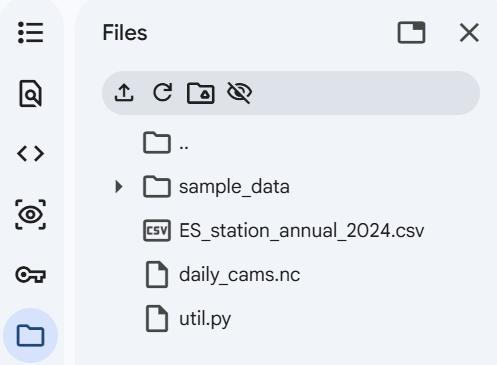


In [ ]:
# If you would like to save this file please uncomment the line below
if (len(Countries)>=1):
    key = 'muti_countries'
else:
    key = Countries[0]
station_table.to_csv(f'{project_dir}/{key}_station_annual_{YEAR}.csv') #aggregated stations average data
# df_2024.to_csv(f'{project_dir}/{key}_station_daily_{YEAR}.csv') #daily data

<a name="7"></a>
## 7 - Visualization
The tool provides both interactive and static plots.

If interactive animation like ipywidgets does not work in your environment, skip the cell below to go to the next cell to plot the static stations plot.



### Map - Corrected annual average PM10 and number of exceedances days

In this section, the corrected annual average PM10 (after subtraction of natural dust contributions) and corrected number of exceedances days (non-dust impacted exceedance days) per station is visualised in an interactive window. Move your cursor to the station location to show the results.

In [36]:

# # Call the defined function to plot the interactive map with new options
# plot_interactive_station_map(
#     df=station_table,
#     color_column='Average_PM10_dust_removed',
#     size_column='NonDust_exceedance',
#     color_type='continuous_scale', # Explicitly continuous
#     colorscale='RdBu_r',
#     zoom=5,
#     map_title='Corrected PM10 concentration (colorbar) and corrected nr. of exceedance days (size of dots)',
#     colorbar_title='µg/m³',
#     size_legend_min=1,
#     size_legend_max=19,
#     size_legend_steps=3,
#     marker_size_range=[20, 40]
# )




### Plot station timeseries


On the interactive map below you can select a station and click to plot the timeseries of measured and corrected PM10.

Color and size of the dots indicate the average PM10 concentration before removing the natural dust contribution.

In [ ]:
# interactive_map_widget = map_timeseries_clickable_plot(
#     obs_df=obs_2024,
#     year=YEAR,
#     exceedance_threshold=PM10_daily_threshold,
#     cams_dust_threshold=CAMS_dust_threshold,
#     legend_title='Average observed PM10 (µg/m³)',
#     legend_bins=7,
#     legend_round=0,
#     radius_range=(8, 16)
# )
# display(interactive_map_widget)

### Static timeseries
If the interactive maps above do not work you can copy the sations name and input below: Remember to uncomment the lines.

In [ ]:
# @title
# ########### USER INPUT ##############
# # print(stations)
# station_name = 'ES/SP_43004006_10_M' # specify station to plot
# #####################################
# # Plot timeseries for this station
# fig, ax = plot_station_timeseries(station_name, obs_2024,
#                        year = YEAR,
#                        exceedance_threshold= PM10_daily_threshold,
#                       cams_dust_threshold= CAMS_dust_threshold)

### Static Map exceedance days

Static plot:

You can chose the column to plot from the station table.

For Custom color option:
https://matplotlib.org/stable/gallery/color/colormap_reference.html

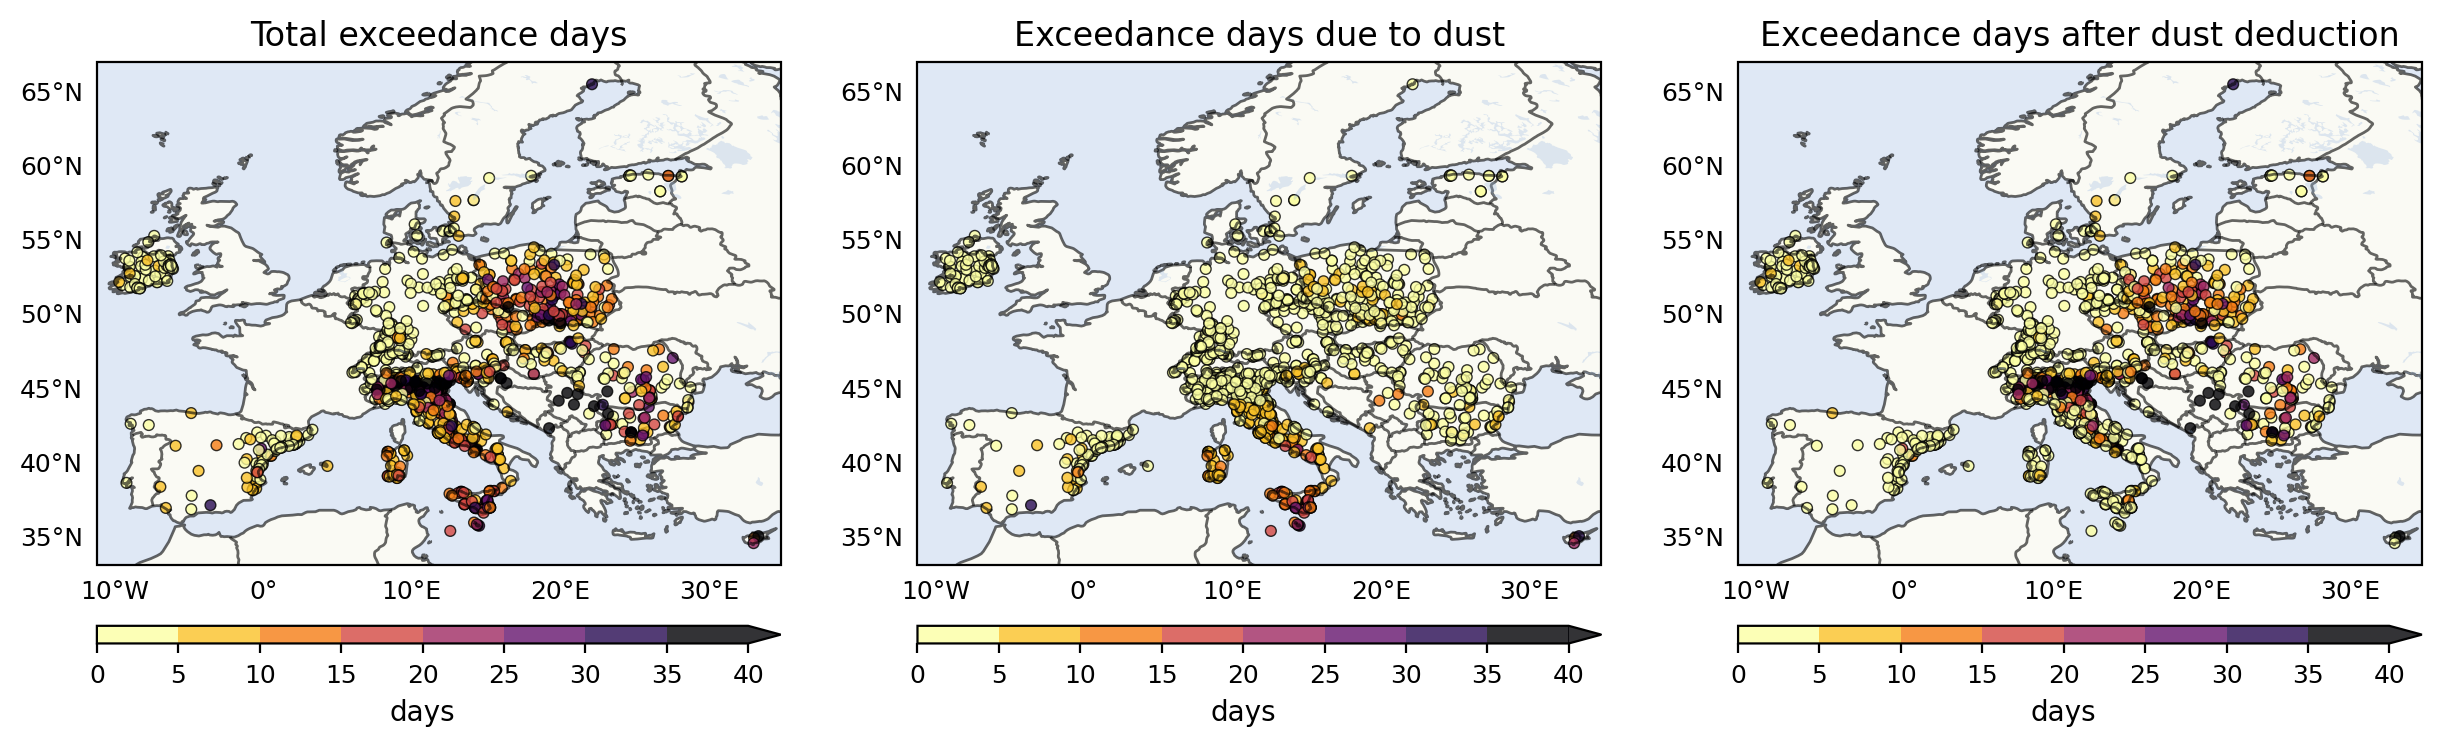

In [37]:
###################Edit here#########################
columns_to_plot = ['Exceedance_days', 'Dust_exceedance_days', 'NonDust_exceedance']
titles = [
    'Total exceedance days',
    'Exceedance days due to dust',
    'Exceedance days after dust deduction'
]
vmax_value = 40
n_colors = 8
colormap='inferno_r' # see https://matplotlib.org/stable/gallery/color/colormap_reference.html for options, for example Set1 gistheat_r twilight
###################Stop here#########################
plot_exceedance_maps_discrete(
    station_table, columns_to_plot, titles, vmax_value,    # data
    n_colors=n_colors,cbar_text='days',cmap_name=colormap, # color setup
    cbar_mode="each",                                       # color bar location "each" each plot would be a individual plot or "single" for panel plot
    cbar_orientation="horizontal",
    cbar_size="3.5%", cbar_pad="12%"                        # size >3% and pad 12% horizontal

)

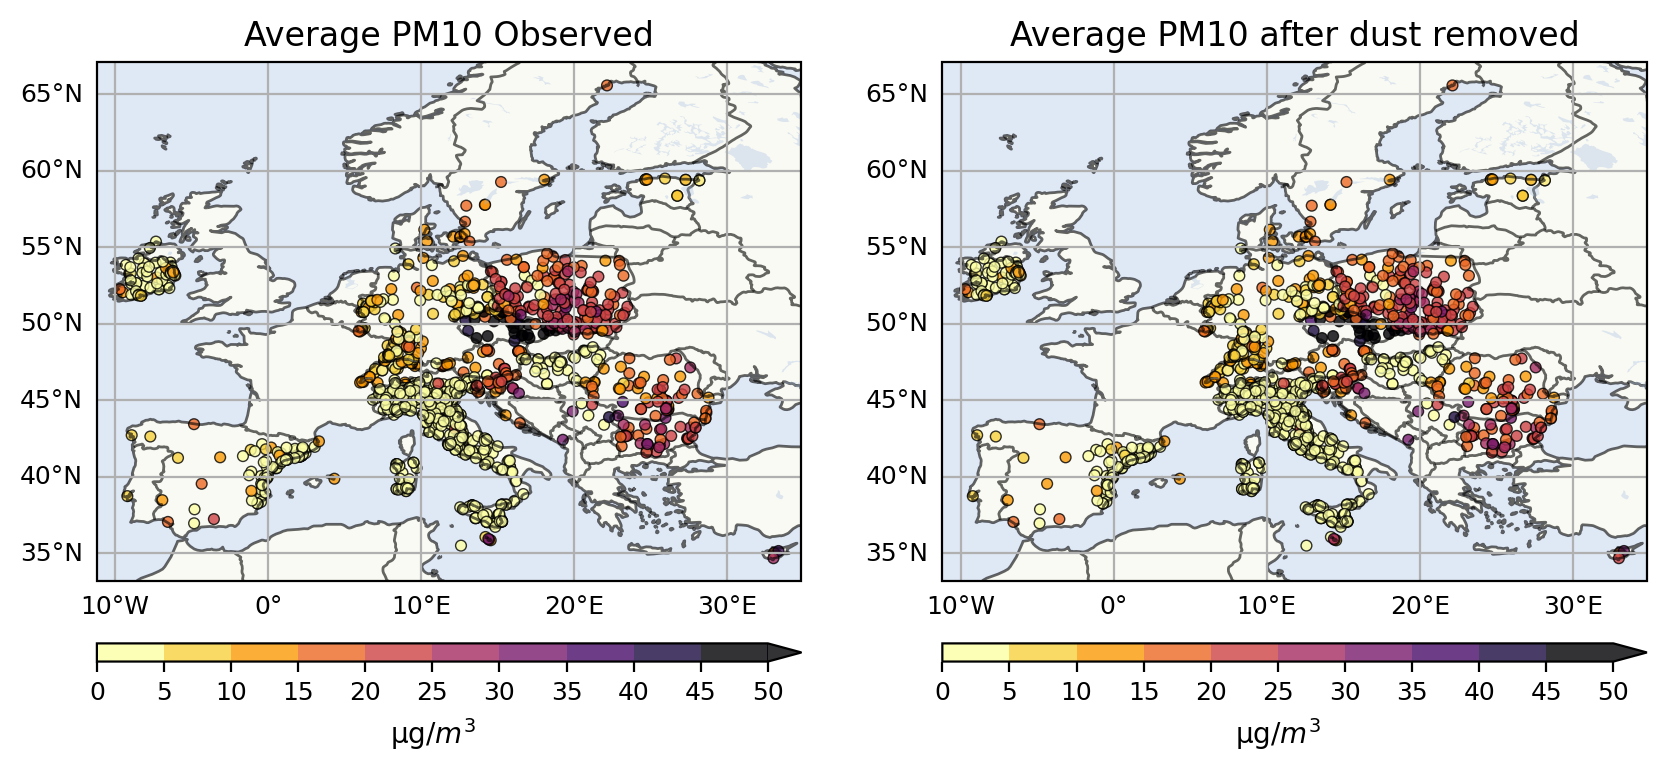

In [38]:
###################Edit here#########################
columns_to_plot = ['Average_PM10', 'Average_PM10_dust_removed']
titles = [
    'Average PM10 Observed',
    'Average PM10 after dust removed'
]
vmax_value = 50
n_colors = 10
colormap='inferno_r' # https://matplotlib.org/stable/gallery/color/colormap_reference.html Set1 gist_heat_r twilight
###################Stop here#########################
import cartopy.crs as ccrs
plot_exceedance_maps_discrete(station_table, columns_to_plot, titles, vmax_value,
    cbar_mode="each",                                       # color bar location "each" each plot would be a individual plot or "single" for panel plot
    cbar_orientation="horizontal",gridline = True,
     n_colors=n_colors,cbar_text='µg/$m^3$',cmap_name=colormap,
    cbar_size="3.5%", cbar_pad="12%" )